# Interpret whole-slide clinical predictions

Run ABMIL inference on HistAgent tile representations, map tile-level scores back to tissue and analyze patient-level prognostic risk.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e .
python -m pip install jupyter numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = Path(configured_data).expanduser() if configured_data else Path("data")
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

def rankridge_pack_root(groups):
    configured = os.getenv("HISTAGENT_RANKRIDGE_PACKS", "").strip()
    if configured:
        root = Path(configured).expanduser()
        if not (root / groups[0]).exists():
            root = root / "rankridge_tutorial_packs"
        assert (root / groups[0]).exists(), f"RankRidge pack not found: {root}"
        return root

    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=[
                f"rankridge_tutorial_packs/{group}/**" for group in groups
            ],
        )
    )
    return snapshot / "rankridge_tutorial_packs"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 135,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
COLORS = {
    "HistAgent": "#168267",
    "Measured ST": "#6f7477",
    "STPath": "#cb77a0",
    "OmiCLIP": "#69aec7",
}
SURVIVAL_COLORS = {"High risk": "#ef4545", "Low risk": "#45b3c2"}
REGION_COLORS = {
    "Poor": "#d85f6b",
    "High": "#79a9d1",
    "Negative": "#b7b7b7",
    "Tumor": "#e32925",
    "Stroma": "#62acec",
}
TASK_CMAPS = {
    "svg": "YlGnBu",
    "domain": "tab10",
    "deconv": "Greens",
    "deg": "Purples",
    "pathway": "PuBuGn",
}

## Overview

Run a trained ABMIL model on HistAgent tile representations, compare the resulting scores across annotated tissue regions and calculate patient-level prognostic risk.

In [2]:
import torch
from torch import nn
from scipy.ndimage import gaussian_filter, maximum_filter
from scipy.stats import mannwhitneyu, chi2

clinical_meta = json.loads((DATA_DIR / "clinical_cases.json").read_text())
survival = pd.read_csv(DATA_DIR / "figure4_survival_oof.csv")
reported = pd.read_json(DATA_DIR / "fig4d_summary.json")

print(f"Clinical examples: {len(clinical_meta['cases'])}")
print(f"Out-of-fold patients: {survival['case_id'].nunique():,}")

Clinical examples: 3
Out-of-fold patients: 843


## Run clinical inference

The instance encoder maps each 512-dimensional HistAgent representation to a 256-dimensional tile representation. The trained prediction head then produces a subtype probability or survival-risk score for each tile. Gated attention aggregates the same tile representations for slide-level prediction.

In [3]:
class GatedAttention(nn.Module):
    def __init__(self, in_dim=256, hidden=256):
        super().__init__()
        self.v = nn.Linear(in_dim, hidden)
        self.u = nn.Linear(in_dim, hidden)
        self.w = nn.Linear(hidden, 1)

    def forward(self, h):
        logits = self.w(
            torch.tanh(self.v(h)) * torch.sigmoid(self.u(h))
        ).squeeze(-1)
        weights = torch.softmax(logits, dim=0)
        return torch.sum(h * weights[:, None], dim=0), weights


class ABMIL(nn.Module):
    def __init__(self, in_dim=512, n_classes=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.attn = GatedAttention()
        self.head = nn.Linear(256, n_classes)

    def forward(self, x):
        h = self.encoder(x)
        slide, attention = self.attn(h)
        return self.head(slide), attention

In [4]:
tile_frames = []
inference_summary = []
for info in clinical_meta["cases"]:
    with np.load(DATA_DIR / info["embedding_file"]) as case_arrays:
        embeddings = case_arrays["embeddings"]
        coords = case_arrays["coords"].copy()
        region_codes = case_arrays["regions"].copy()

    model = ABMIL(n_classes=info["n_classes"])
    state = torch.load(
        DATA_DIR / info["checkpoint"],
        map_location="cpu",
        weights_only=True,
    )
    model.load_state_dict(state)
    model.eval()

    with torch.no_grad():
        encoded_tiles = torch.cat([
            model.encoder(torch.from_numpy(embeddings[start:start + 4096]).float())
            for start in range(0, len(embeddings), 4096)
        ])
        tile_logits = model.head(encoded_tiles)
        slide_representation, attention = model.attn(encoded_tiles)
        slide_logits = model.head(slide_representation)
        if info["n_classes"] > 1:
            tile_score = torch.softmax(tile_logits, dim=1)[
                :, info["target_index"]
            ]
            slide_score = torch.softmax(slide_logits, dim=0)[
                info["target_index"]
            ].item()
        else:
            tile_score = tile_logits[:, 0]
            slide_score = slide_logits[0].item()

    region_labels = [
        "Unannotated" if code < 0 else info["region_names"][int(code)]
        for code in region_codes
    ]
    tile_frames.append(pd.DataFrame({
        "cohort": info["cohort"],
        "case": info["case"],
        "x": coords[:, 0],
        "y": coords[:, 1],
        "region_code": region_codes,
        "region": region_labels,
        "score": tile_score.numpy(),
        "attention": attention.numpy(),
    }))
    inference_summary.append({
        "cohort": info["cohort"],
        "case": info["case"],
        "tiles": len(coords),
        "annotated_tiles": int((region_codes >= 0).sum()),
        "slide_score": slide_score,
    })
    del embeddings, encoded_tiles, tile_logits, tile_score, attention

tiles = pd.concat(tile_frames, ignore_index=True)
display(pd.DataFrame(inference_summary).round(3))
tiles.query("region_code >= 0").groupby(
    ["cohort", "case", "region"]
).agg(
    tiles=("score", "size"),
    mean_score=("score", "mean"),
).round(3)

,cohort,case,tiles,annotated_tiles,slide_score
0,STAD,TCGA-VQ-AA6B,73724,28679,0.854
1,STAD,TCGA-BR-8486,77760,62494,0.597
2,BRCA,TCGA-E2-A1LH,75260,145,-1.644


tiles  mean_score
cohort case         region                   
BRCA   TCGA-E2-A1LH Stroma     66      -3.204
                    Tumor      79      -0.918
STAD   TCGA-BR-8486 High    10112       0.278
                    Poor    52382       0.415
       TCGA-VQ-AA6B High      318       0.407
                    Poor    28361       0.755

## Compare annotated tissue regions

The same tile scores are used for the spatial maps and the region-level tests. STAD compares poorly and highly differentiated tissue; BRCA compares tumor and stroma within the annotated ROI.

In [5]:
expected_region_pairs = {
    "STAD": ("Poor", "High"),
    "BRCA": ("Tumor", "Stroma"),
}
region_tests = []
for (cohort, case), frame in tiles.groupby(["cohort", "case"]):
    region_1, region_2 = expected_region_pairs[cohort]
    a = frame.loc[frame["region"] == region_1, "score"].to_numpy()
    b = frame.loc[frame["region"] == region_2, "score"].to_numpy()
    test = mannwhitneyu(a, b, alternative="greater")
    region_tests.append({
        "cohort": cohort,
        "case": case,
        "comparison": f"{region_1} > {region_2}",
        "Mann–Whitney P": test.pvalue,
    })
region_tests = pd.DataFrame(region_tests)
region_tests

,cohort,case,comparison,Mann–Whitney P
0,BRCA,TCGA-E2-A1LH,Tumor > Stroma,6.375774e-12
1,STAD,TCGA-BR-8486,Poor > High,0.000000e+00
2,STAD,TCGA-VQ-AA6B,Poor > High,2.022904e-144


## Spatial visualization of clinical scores

Map the computed tile-level scores back to the two STAD whole-slide examples and the BRCA ROI.

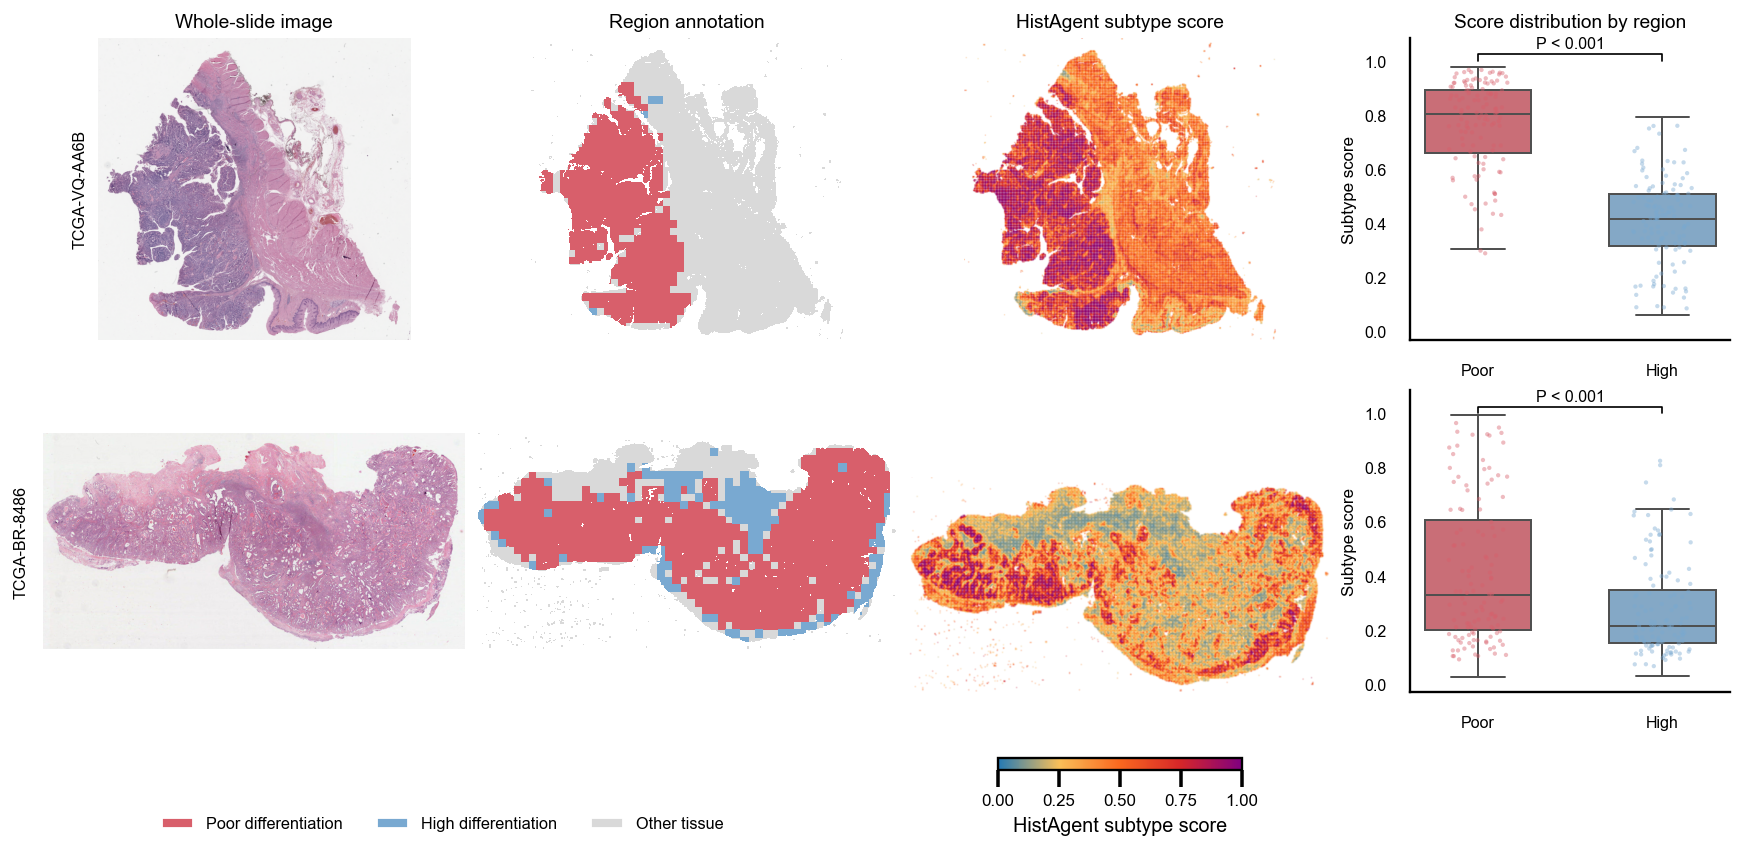

In [6]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgba
from matplotlib.patches import Patch

wsi_dir = DATA_DIR / "figure4_wsi"
risk_cmap = LinearSegmentedColormap.from_list(
    "histagent_risk",
    ["#2178B5", "#F9BF59", "#FA681F", "#D62629", "#800080"],
)

def slide_bounds(info):
    return (0, 0, info["slide_width"], info["slide_height"])

def show_image(ax, filename, bounds):
    xmin, ymin, xmax, ymax = bounds
    ax.imshow(
        plt.imread(wsi_dir / filename),
        extent=[xmin, xmax, ymax, ymin],
        origin="upper",
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()

def _raster_geometry(bounds, width=900):
    xmin, ymin, xmax, ymax = bounds
    height = max(1, round(width * (ymax - ymin) / (xmax - xmin)))
    return int(width), int(height)

def score_raster(frame, bounds, vmin, vmax, width=900, sigma=1.15):
    xmin, ymin, xmax, ymax = bounds
    width, height = _raster_geometry(bounds, width)
    x_index = np.clip(
        ((frame["x"].to_numpy() - xmin) / (xmax - xmin) * (width - 1)).astype(int),
        0, width - 1,
    )
    y_index = np.clip(
        ((frame["y"].to_numpy() - ymin) / (ymax - ymin) * (height - 1)).astype(int),
        0, height - 1,
    )
    weighted = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)
    np.add.at(weighted, (y_index, x_index), frame["score"].to_numpy())
    np.add.at(counts, (y_index, x_index), 1)
    weighted = gaussian_filter(weighted, sigma=sigma)
    support = gaussian_filter(counts, sigma=sigma)
    field = np.divide(
        weighted, support, out=np.zeros_like(weighted), where=support > 1e-5
    )
    rgba = risk_cmap(Normalize(vmin, vmax, clip=True)(field))
    rgba[..., 3] = np.clip(support / max(np.percentile(support[support > 0], 65), 1e-6), 0, 1)
    rgba[support < .006, 3] = 0
    return rgba

def tile_score_raster(
    frame, bounds, tile_size, vmin, vmax, width=720
):
    xmin, ymin, xmax, ymax = bounds
    width, height = _raster_geometry(bounds, width)
    tile_width = max(1, round(tile_size / (xmax - xmin) * width) + 2)
    tile_height = max(1, round(tile_size / (ymax - ymin) * height) + 2)
    heat = np.zeros((height, width), dtype=np.float32)
    counts = np.zeros((height, width), dtype=np.float32)
    for row in frame.itertuples():
        left = int(np.clip(
            (row.x - xmin) / (xmax - xmin) * width, 0, width - 1
        ))
        top = int(np.clip(
            (row.y - ymin) / (ymax - ymin) * height, 0, height - 1
        ))
        right = min(width, left + tile_width)
        bottom = min(height, top + tile_height)
        heat[top:bottom, left:right] += row.score
        counts[top:bottom, left:right] += 1
    tissue = counts > 0
    heat = np.divide(
        heat, counts, out=np.zeros_like(heat), where=tissue
    )
    heat = gaussian_filter(
        heat, sigma=max(1.0, min(tile_width, tile_height) * .58)
    )
    rgba = risk_cmap(Normalize(vmin, vmax, clip=True)(heat))
    rgba[..., 3] = np.where(tissue, .84, 0)
    return rgba

def region_raster(frame, bounds, width=900):
    xmin, ymin, xmax, ymax = bounds
    width, height = _raster_geometry(bounds, width)
    x_index = np.clip(
        ((frame["x"].to_numpy() - xmin) / (xmax - xmin) * (width - 1)).astype(int),
        0, width - 1,
    )
    y_index = np.clip(
        ((frame["y"].to_numpy() - ymin) / (ymax - ymin) * (height - 1)).astype(int),
        0, height - 1,
    )
    rgba = np.zeros((height, width, 4), dtype=float)
    for code, color in [
        (-1, "#D9D9D9"),
        (0, REGION_COLORS["Poor"]),
        (1, REGION_COLORS["High"]),
    ]:
        mask = np.zeros((height, width), dtype=np.uint8)
        selected = frame["region_code"].to_numpy() == code
        mask[y_index[selected], x_index[selected]] = 1
        mask = maximum_filter(mask, size=3) > 0
        rgba[mask] = to_rgba(color)
    return rgba

def show_raster(ax, rgba, bounds, interpolation="nearest"):
    xmin, ymin, xmax, ymax = bounds
    ax.imshow(
        rgba, extent=[xmin, xmax, ymax, ymin],
        origin="upper", interpolation=interpolation,
    )
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymax, ymin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_axis_off()

stad_cases = [case for case in clinical_meta["cases"] if case["cohort"] == "STAD"]
fig, axes = plt.subplots(
    2, 4, figsize=(12.8, 6.15),
    gridspec_kw={"width_ratios": [1.08, 1.08, 1.08, .82]},
    constrained_layout=True,
)
column_titles = [
    "Whole-slide image",
    "Region annotation",
    "HistAgent subtype score",
    "Score distribution by region",
]

for row_i, info in enumerate(stad_cases):
    bounds = slide_bounds(info)
    case_id = info["case"]
    frame = tiles.query("cohort == 'STAD' and case == @case_id").copy()
    annotated = frame.query("region_code >= 0").copy()

    show_image(axes[row_i, 0], info["thumbnail"], bounds)
    show_raster(axes[row_i, 1], region_raster(frame, bounds), bounds)
    show_raster(
        axes[row_i, 2],
        score_raster(frame, bounds, vmin=0, vmax=1),
        bounds,
        interpolation="bilinear",
    )

    order = ["Poor", "High"]
    point_sample = pd.concat([
        part.sample(min(len(part), 120), random_state=11)
        for _, part in annotated.groupby("region", sort=False)
    ])
    sns.boxplot(
        data=annotated, x="region", y="score", order=order, hue="region",
        palette=REGION_COLORS, showfliers=False, width=.58,
        linewidth=1.05, legend=False, ax=axes[row_i, 3],
    )
    sns.stripplot(
        data=point_sample, x="region", y="score", order=order, hue="region",
        palette=REGION_COLORS, size=2.3, alpha=.42,
        jitter=.16, legend=False, ax=axes[row_i, 3],
    )
    poor = annotated.loc[annotated["region"] == "Poor", "score"].to_numpy()
    high = annotated.loc[annotated["region"] == "High", "score"].to_numpy()
    p_value = mannwhitneyu(poor, high, alternative="greater").pvalue
    axes[row_i, 3].plot(
        [0, 0, 1, 1], [1.00, 1.025, 1.025, 1.00],
        color="black", linewidth=.9,
    )
    axes[row_i, 3].text(
        .5, 1.035, "P < 0.001" if p_value < .001 else f"P = {p_value:.3f}",
        ha="center", va="bottom", fontsize=8.5,
    )
    axes[row_i, 3].set_ylim(-.03, 1.085)
    axes[row_i, 3].set_xlabel("")
    axes[row_i, 3].set_ylabel("Subtype score", fontsize=9)
    axes[row_i, 3].tick_params(labelsize=8.5, colors="black")
    sns.despine(ax=axes[row_i, 3])

    axes[row_i, 0].text(
        -.035, .5, info["case"], transform=axes[row_i, 0].transAxes,
        rotation=90, va="center", ha="right", fontsize=8.5,
    )
    if row_i == 0:
        for ax, title in zip(axes[row_i], column_titles):
            ax.set_title(title, pad=6, fontsize=10.2)

fig.legend(
    handles=[
        Patch(facecolor=REGION_COLORS["Poor"], label="Poor differentiation"),
        Patch(facecolor=REGION_COLORS["High"], label="High differentiation"),
        Patch(facecolor="#D9D9D9", label="Other tissue"),
    ],
    loc="lower left", bbox_to_anchor=(.08, -.01), ncol=3,
    frameon=False, fontsize=8.7,
)
fig.colorbar(
    ScalarMappable(norm=Normalize(0, 1), cmap=risk_cmap),
    ax=axes[:, 2].tolist(), orientation="horizontal",
    shrink=.58, pad=.035, label="HistAgent subtype score",
)
plt.show()

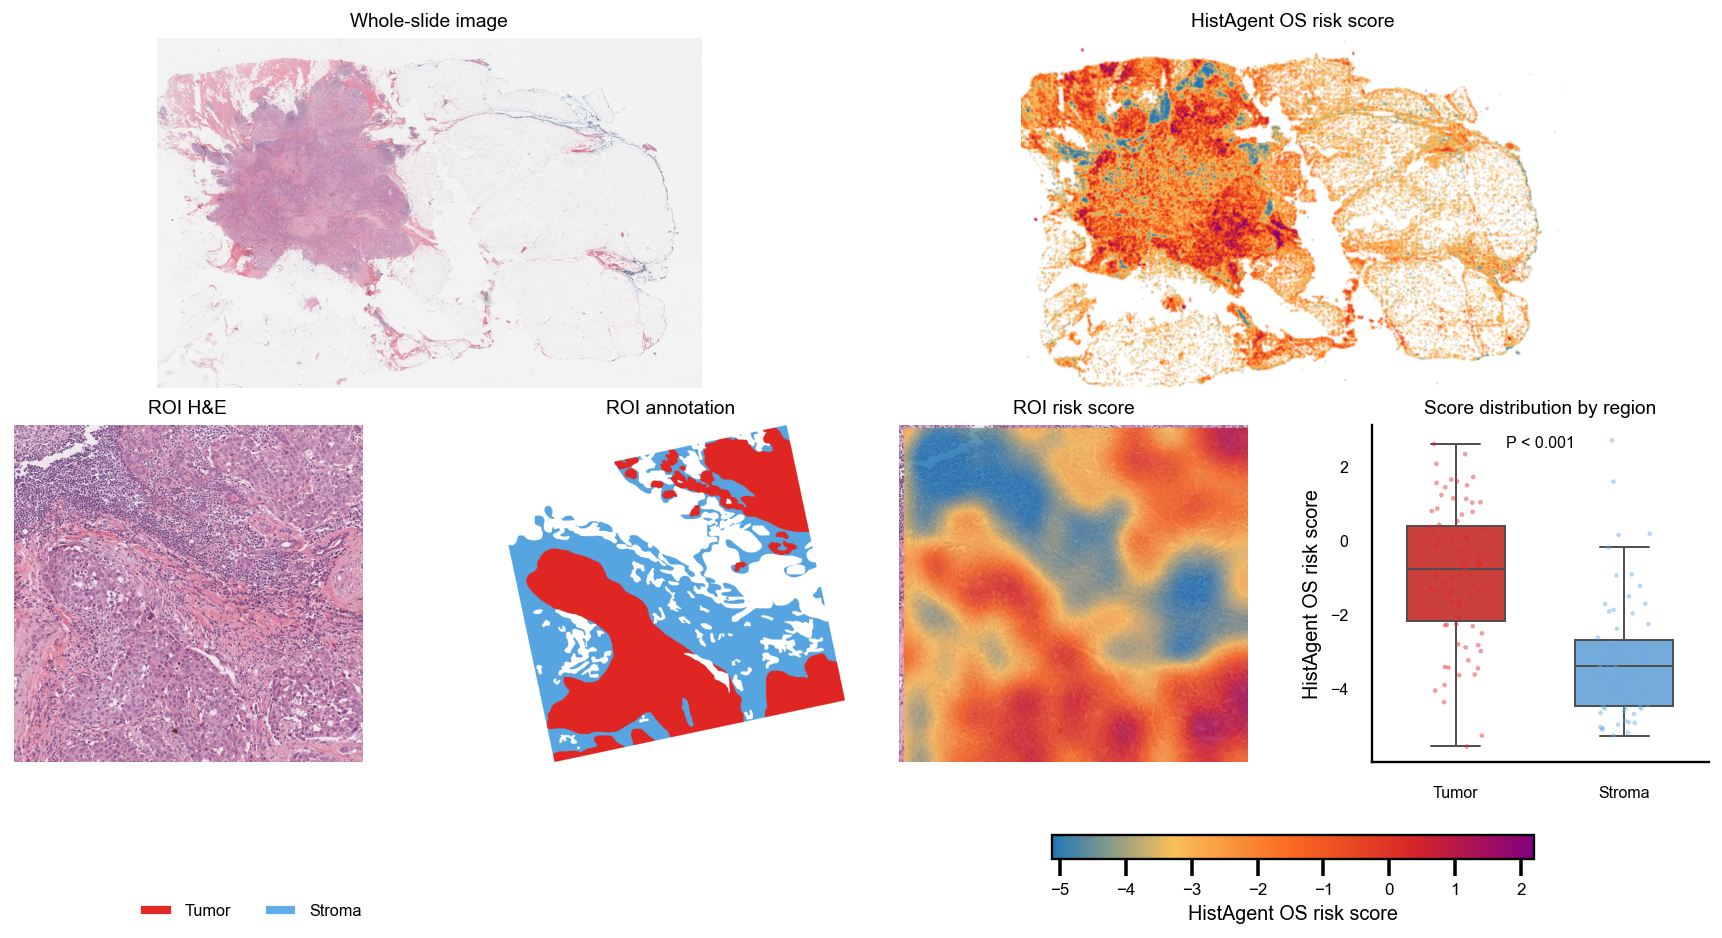

In [7]:
brca_info = next(
    case for case in clinical_meta["cases"] if case["cohort"] == "BRCA"
)
brca_frame = tiles.query("cohort == 'BRCA'").copy()
brca_annotated = brca_frame.query("region_code >= 0").copy()
full_bounds = slide_bounds(brca_info)
roi_bounds = tuple(brca_info["roi_bounds"][key] for key in [
    "xmin", "ymin", "xmax", "ymax"
])
roi_frame = brca_frame.loc[
    brca_frame["x"].between(roi_bounds[0], roi_bounds[2])
    & brca_frame["y"].between(roi_bounds[1], roi_bounds[3])
].copy()
risk_low, risk_high = np.percentile(brca_frame["score"], [2, 98])

fig = plt.figure(figsize=(12.8, 6.8), constrained_layout=True)
grid = fig.add_gridspec(
    2, 4, height_ratios=[1.04, 1],
    width_ratios=[1, 1, 1, .86],
)
brca_axes = {
    "wsi": fig.add_subplot(grid[0, :2]),
    "wsi_score": fig.add_subplot(grid[0, 2:]),
    "roi": fig.add_subplot(grid[1, 0]),
    "roi_region": fig.add_subplot(grid[1, 1]),
    "roi_score": fig.add_subplot(grid[1, 2]),
    "distribution": fig.add_subplot(grid[1, 3]),
}
show_image(
    brca_axes["wsi"], brca_info["thumbnail"], full_bounds
)
brca_axes["wsi"].set_title("Whole-slide image", pad=6, fontsize=10.2)

show_raster(
    brca_axes["wsi_score"],
    score_raster(
        brca_frame, full_bounds, risk_low, risk_high,
        width=1000, sigma=1.25,
    ),
    full_bounds,
    interpolation="bilinear",
)
brca_axes["wsi_score"].set_title(
    "HistAgent OS risk score", pad=6, fontsize=10.2
)

show_image(brca_axes["roi"], brca_info["roi_image"], roi_bounds)
brca_axes["roi"].set_title("ROI H&E", pad=6, fontsize=10.2)
show_image(
    brca_axes["roi_region"], brca_info["roi_annotation"], roi_bounds
)
brca_axes["roi_region"].set_title("ROI annotation", pad=6, fontsize=10.2)
show_image(brca_axes["roi_score"], brca_info["roi_image"], roi_bounds)
show_raster(
    brca_axes["roi_score"],
    tile_score_raster(
        roi_frame, roi_bounds, brca_info["tile_size_level0_px"],
        risk_low, risk_high,
    ),
    roi_bounds,
    interpolation="bilinear",
)
brca_axes["roi_score"].set_title("ROI risk score", pad=6, fontsize=10.2)

distribution_ax = brca_axes["distribution"]
order = ["Tumor", "Stroma"]
sns.boxplot(
    data=brca_annotated, x="region", y="score", order=order, hue="region",
    palette=REGION_COLORS, showfliers=False, width=.58,
    linewidth=1.05, legend=False, ax=distribution_ax,
)
sns.stripplot(
    data=brca_annotated, x="region", y="score", order=order, hue="region",
    palette=REGION_COLORS, size=2.5, alpha=.45, jitter=.16,
    legend=False, ax=distribution_ax,
)
p_value = region_tests.query("cohort == 'BRCA'")["Mann–Whitney P"].iloc[0]
distribution_ax.set_title("Score distribution by region", pad=6, fontsize=10.2)
distribution_ax.set_xlabel("")
distribution_ax.set_ylabel("HistAgent OS risk score")
distribution_ax.text(
    .5, .97, "P < 0.001" if p_value < .001 else f"P = {p_value:.3f}",
    transform=distribution_ax.transAxes, ha="center", va="top", fontsize=8.5,
)
distribution_ax.tick_params(labelsize=8.5, colors="black")
sns.despine(ax=distribution_ax)

fig.legend(
    handles=[
        Patch(facecolor=REGION_COLORS["Tumor"], label="Tumor"),
        Patch(facecolor=REGION_COLORS["Stroma"], label="Stroma"),
    ],
    loc="lower left", bbox_to_anchor=(0.08, -0.008),
    ncol=2, frameon=False, fontsize=8.7,
)
fig.colorbar(
    ScalarMappable(
        norm=Normalize(risk_low, risk_high), cmap=risk_cmap
    ),
    ax=[brca_axes["wsi_score"], brca_axes["roi_score"]],
    location="bottom", shrink=.58, pad=.04,
    label="HistAgent OS risk score",
)
plt.show()

## Patient-level prognostic-risk stratification

Each cohort is split at its median out-of-fold risk. The code below calculates the Kaplan-Meier curves and log-rank p-values.

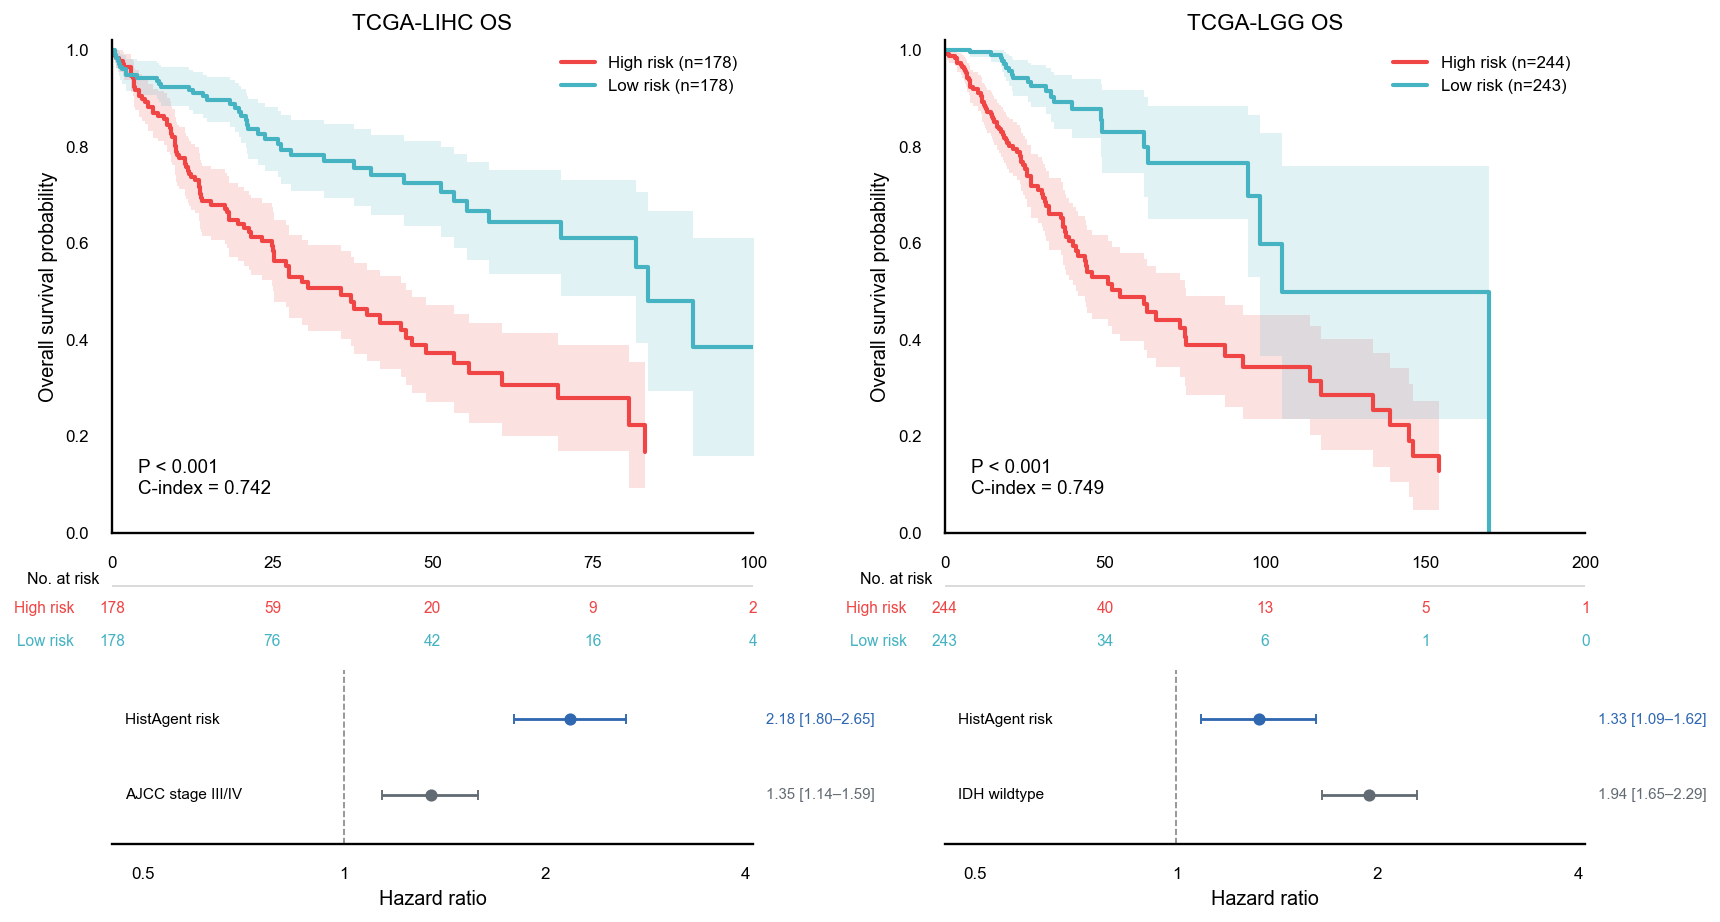

,Cohort,C-index,Log-rank P
0,LIHC,0.742,0.0
1,LGG,0.749,0.0


In [8]:
def km_curve(time, event):
    order = np.argsort(time)
    time = np.asarray(time)[order]
    event = np.asarray(event)[order].astype(int)
    event_times = np.unique(time[event == 1])
    surv = 1.0
    variance_sum = 0.0
    xs, ys, lower, upper = [0.0], [1.0], [1.0], [1.0]
    for t in event_times:
        at_risk = np.sum(time >= t)
        deaths = np.sum((time == t) & (event == 1))
        se_before = surv * np.sqrt(variance_sum)
        xs.extend([t, t])
        ys.extend([ys[-1], surv * (1 - deaths / at_risk)])
        lower.append(max(0, surv - 1.96 * se_before))
        upper.append(min(1, surv + 1.96 * se_before))
        if at_risk - deaths > 0:
            variance_sum += deaths / (at_risk * (at_risk - deaths))
        surv = ys[-1]
        se_after = surv * np.sqrt(variance_sum)
        lower.append(max(0, surv - 1.96 * se_after))
        upper.append(min(1, surv + 1.96 * se_after))
    return (
        np.asarray(xs), np.asarray(ys),
        np.asarray(lower), np.asarray(upper),
    )


def logrank_p(time, event, group):
    time = np.asarray(time)
    event = np.asarray(event).astype(int)
    group = np.asarray(group).astype(bool)
    observed = expected = variance = 0.0
    for t in np.unique(time[event == 1]):
        at_risk = time >= t
        n = at_risk.sum()
        n1 = (at_risk & group).sum()
        d = ((time == t) & (event == 1)).sum()
        d1 = ((time == t) & (event == 1) & group).sum()
        if n <= 1:
            continue
        observed += d1
        expected += d * n1 / n
        variance += d * (n1 / n) * (1 - n1 / n) * ((n - d) / (n - 1))
    statistic = (observed - expected) ** 2 / variance
    return chi2.sf(statistic, 1)


survival["cohort"] = survival["task"].str.replace("TCGA-", "", regex=False)
survival["cohort"] = survival["cohort"].str.replace("__OS", "", regex=False)
survival["risk_group"] = survival.groupby("cohort")["risk"].transform(
    lambda x: np.where(x >= x.median(), "High risk", "Low risk")
)

cohort_order = ["LIHC", "LGG"]
time_ticks = {
    "LIHC": np.array([0, 25, 50, 75, 100]),
    "LGG": np.array([0, 50, 100, 150, 200]),
}
cox_rows = reported.query("analysis == 'Cox'").copy()
fig = plt.figure(figsize=(12.4, 7.0), facecolor="white")
outer = fig.add_gridspec(
    1, 2, left=.08, right=.96, top=.94, bottom=.09, wspace=.30
)
km_results = []
for column, cohort in enumerate(cohort_order):
    frame = survival.query("cohort == @cohort").copy()
    subgrid = outer[column].subgridspec(
        3, 1, height_ratios=[3.35, .66, 1.18], hspace=.08
    )
    ax = fig.add_subplot(subgrid[0])
    risk_ax = fig.add_subplot(subgrid[1], sharex=ax)
    forest_ax = fig.add_subplot(subgrid[2])

    for group in ["High risk", "Low risk"]:
        color = SURVIVAL_COLORS[group]
        part = frame.query("risk_group == @group")
        x, y, low, high = km_curve(part["time"], part["event"])
        ax.fill_between(
            x, low, high, step="post", color=color, alpha=.16, linewidth=0
        )
        ax.step(x, y, where="post", label=f"{group} (n={len(part)})",
                color=color, linewidth=2.2)
    p = logrank_p(frame["time"], frame["event"],
                  frame["risk_group"].eq("High risk"))
    c_index = float(
        reported.query(
            "cohort == @cohort and analysis == 'Kaplan–Meier' "
            "and quantity_or_covariate == 'C-index'"
        )["estimate"].iloc[0]
    )
    km_results.append({
        "Cohort": cohort, "C-index": c_index, "Log-rank P": p
    })
    ax.set_title(f"TCGA-{cohort} OS")
    ax.set_ylabel("Overall survival probability")
    ax.set_ylim(0, 1.02)
    ax.set_xlim(0, time_ticks[cohort][-1])
    ax.set_xticks(time_ticks[cohort])
    p_label = "P < 0.001" if p < .001 else f"P = {p:.3f}"
    ax.text(
        .04, .08, f"{p_label}\nC-index = {c_index:.3f}",
        transform=ax.transAxes,
    )
    ax.legend(frameon=False)
    sns.despine(ax=ax)

    risk_ax.set_ylim(0, 1)
    risk_ax.set_axis_off()
    risk_ax.text(
        -.02, .73, "No. at risk", transform=risk_ax.transAxes,
        ha="right", va="center", fontsize=8.5,
    )
    group_rows = [("High risk", .43), ("Low risk", .09)]
    for group, y_position in group_rows:
        color = SURVIVAL_COLORS[group]
        group_mask = frame["risk_group"].eq(group).to_numpy()
        risk_ax.text(
            -.06, y_position, group, transform=risk_ax.transAxes,
            ha="right", va="center", fontsize=8.3, color=color,
        )
        for tick in time_ticks[cohort]:
            count = int(
                ((frame["time"].to_numpy() >= tick) & group_mask).sum()
            )
            risk_ax.text(
                tick, y_position, str(count),
                ha="center", va="center", fontsize=8.3, color=color,
            )
    risk_ax.axhline(.66, color="#D0D0D0", linewidth=.8)

    cohort_forest = cox_rows.query("cohort == @cohort").reset_index(drop=True)
    forest_ax.axvline(1, color="#888888", linestyle="--", linewidth=.9)
    y_positions = [1, 0]
    for y_position, row in zip(y_positions, cohort_forest.itertuples()):
        is_histagent = str(row.quantity_or_covariate).startswith("HistAgent")
        color = "#2F67B1" if is_histagent else "#626B73"
        forest_ax.errorbar(
            row.hazard_ratio, y_position,
            xerr=[[row.hazard_ratio - row.ci_low],
                  [row.ci_high - row.hazard_ratio]],
            fmt="o", color=color, ecolor=color, capsize=2.5,
            markersize=5.5, linewidth=1.5,
        )
        label = (
            "HistAgent risk"
            if is_histagent else str(row.quantity_or_covariate)
        )
        forest_ax.text(
            .47, y_position, label,
            ha="left", va="center", fontsize=8.2,
        )
        forest_ax.text(
            1.02, y_position,
            f"{row.hazard_ratio:.2f} [{row.ci_low:.2f}–{row.ci_high:.2f}]",
            transform=forest_ax.get_yaxis_transform(),
            ha="left", va="center", fontsize=8.0, color=color,
        )
    forest_ax.set_xscale("log")
    forest_ax.set_xlim(.45, 4.1)
    forest_ax.set_xticks([.5, 1, 2, 4], labels=["0.5", "1", "2", "4"])
    forest_ax.set_ylim(-.65, 1.65)
    forest_ax.set_yticks([])
    forest_ax.set_xlabel("Hazard ratio")
    forest_ax.minorticks_off()
    sns.despine(ax=forest_ax, left=True)

plt.show()
pd.DataFrame(km_results).round(3)

## Multivariable prognostic analysis

The forest plot uses the reported Cox model estimates. HistAgent risk is entered per standard deviation together with the cohort-specific clinical covariate.

In [9]:
forest_table = reported.query("analysis == 'Cox'").rename(columns={
    "cohort": "Cohort",
    "quantity_or_covariate": "Covariate",
    "hazard_ratio": "Hazard ratio",
}).copy()
forest_table["95% CI"] = forest_table.apply(
    lambda row: f"{row['ci_low']:.2f}–{row['ci_high']:.2f}", axis=1
)
forest_table[["Cohort", "Covariate", "Hazard ratio", "95% CI"]]

,Cohort,Covariate,Hazard ratio,95% CI
5,LIHC,HistAgent risk per 1 SD,2.18,1.80–2.65
6,LIHC,AJCC stage III/IV,1.35,1.14–1.59
12,LGG,HistAgent risk per 1 SD,1.33,1.09–1.62
13,LGG,IDH wildtype,1.94,1.65–2.29


## Verify the calculations

In [10]:
assert len(clinical_meta["cases"]) == 3
for info in clinical_meta["cases"]:
    assert (DATA_DIR / info["checkpoint"]).exists()
    with np.load(DATA_DIR / info["embedding_file"]) as case_arrays:
        assert (
            len(case_arrays["embeddings"])
            == len(case_arrays["coords"])
            == len(case_arrays["regions"])
        )
        assert len(case_arrays["embeddings"]) > 70_000
assert not survival["case_id"].duplicated().any()
assert set(survival["cohort"]) == {"LIHC", "LGG"}
assert all((wsi_dir / info["thumbnail"]).exists() for info in clinical_meta["cases"])
assert (wsi_dir / brca_info["roi_image"]).exists()
assert (wsi_dir / brca_info["roi_annotation"]).exists()
reported_n = (
    reported.query("analysis == 'Kaplan–Meier' and quantity_or_covariate == 'patients'")
    .set_index("cohort")["estimate"].astype(int).to_dict()
)
for cohort, frame in survival.groupby("cohort"):
    assert abs(len(frame) - reported_n[cohort]) <= 1
    assert abs(frame["risk_group"].value_counts().diff().dropna()).max() <= 1
assert len(region_tests) == 3
assert np.isfinite(region_tests["Mann–Whitney P"]).all()
assert tiles.groupby("case").size().min() > 70_000
print("Checks passed for full-slide ABMIL inference, three region contrasts and two patient cohorts.")

Checks passed for full-slide ABMIL inference, three region contrasts and two patient cohorts.


## Continue

Continue to **ST atlas retrieval** to visualize the spatial transcriptomics atlas and run natural-language and H&E image queries.